# Activity 1: Missing Data Diagnosis and Imputation

**Week 6 Day 2 · Machine Learning for Data Cleaning**

**Estimated time:** 75 minutes (Parts 1 to 8), plus 30 minutes for Your Turn
**Difficulty:** Intermediate
**Format:** Individual, with pair discussion at each checkpoint
**Prerequisites:** pandas basics (Week 2 Day 4), comfort reading a scatter plot

## Not all machine learning predicts the future

When people hear "machine learning" they think prediction: forecast the revenue, score the risk, recommend the product. That is one use. It is not the only one, and for a data engineer it is often not the most valuable one.

A large share of the ML that runs in production pipelines never predicts anything a business user sees. It **repairs data**. It fills gaps, flags records that do not belong, and standardises messy inputs before anyone downstream writes a query against them.

That is what today is about. Today you use ML as a **cleaning tool**, not a crystal ball.

## Why missing data is a data engineering problem

Missing data is not a modelling inconvenience you hand to a data scientist. It is a pipeline problem, and it is yours:

- A `NULL` in a join key silently drops rows from a report.
- A missing numeric value turns an `AVG()` into a lie, because SQL skips nulls rather than counting them as zero.
- A column that arrives 5 percent empty on Monday and 40 percent empty on Tuesday is an upstream incident, and you are the one who should catch it.

The engineer's job is to **detect** missingness, **classify** it, **decide** what to do about it, and **prove** the decision was reasonable.

## What makes this activity different

Most tutorials on imputation ask you to take it on faith that the sophisticated method is better. This one does not.

For every dataset here, you have the **original file before values were removed**. That means you can score every imputation strategy against the truth and see exactly how wrong each one is. You will not be guessing which method is better. You will be measuring it.

By the end you will have found at least one result that contradicts the conventional advice.

## Learning objectives

By the end of this activity you will be able to:

1. Distinguish the four ways missing data shows up in pandas: `NaN`, `NaT`, string placeholders, and numeric sentinels.
2. Explain why `.isna()` alone is not a data quality check.
3. Classify missingness as MCAR, MAR, or MNAR, and explain why the classification changes your response.
4. Score any imputation strategy against ground truth using RMSE.
5. Choose between univariate, time-aware, and multivariate ML imputation based on measured evidence rather than reputation.

---
## Setup

One idea per cell from here on. Run them in order.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 12)

This activity uses `matplotlib` for the plots and `scikit-learn` for the imputers in Part 6, on top of the base project's `pandas` and `numpy`. All four are declared in the repo-root `pyproject.toml`, so `uv sync` from the repository root installs them. Run that once if you have not since they were added.

The next cell also builds `DATA_DIR` by walking up from wherever the notebook is running until it finds `pyproject.toml`, the marker for the repository root. That means the path resolves correctly whether you run this notebook from the course folder or from your own copy under `student-work/week6/day2/`, without you hardcoding it.

In [2]:
from pathlib import Path


def find_repo_root(start=None):
    """Walk upward until we find the repo root (the folder holding pyproject.toml)."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from " + str(start))


DATA_DIR = find_repo_root() / "Week 6" / "Labs" / "Day 2" / "data"
print(DATA_DIR)

/Users/tarekatwan/Repos/MyWork/Teach/repos/TechCatalyst_DE_2026/Week 6/Labs/Day 2/data


---
# Part 1: The four faces of missing data

Missing data does not always announce itself. Pandas has a specific idea of what "missing" means, and real files routinely disagree with it.

There are four distinct forms you need to recognise. Only the first two are ones pandas finds for you.

## Face 1: `NaN`, the one everybody knows

`NaN` stands for Not a Number. It is the standard missing marker for numeric columns.

Load the clickstream file and look at it.

In [3]:
clicks = pd.read_csv(DATA_DIR / "clicks_missing.csv")
clicks.head()

,date,price,location,clicks
0,4/1/2008,43.155647,2,18784.0
1,4/2/2008,43.079056,1,24738.0
2,4/3/2008,43.842609,2,15209.0
3,4/4/2008,43.312376,1,14018.0
4,4/5/2008,43.941176,1,11974.0


In [4]:
clicks.isna().sum()

date         0
price        0
location     0
clicks      16
dtype: int64

Sixteen missing values in `clicks`. Straightforward so far.

Now notice something about the **dtype** of that column.

In [5]:
clicks.dtypes

date            str
price       float64
location      int64
clicks      float64
dtype: object

`clicks` is `float64`, even though a click count is obviously a whole number.

That is not a mistake in the data. `NaN` is defined as a floating point value, so the moment a single `NaN` lands in an integer column, pandas has to widen the whole column to float to hold it.

This matters in a pipeline. If you write that column to Parquet and a downstream job expects an integer type, the schema has changed underneath it because of one missing value.

## Face 2: `NaT`, the missing timestamp

`NaN` is for numbers. Dates get their own marker: `NaT`, meaning Not a Time.

The `clicks_missing_multiple.csv` file has gaps in its date column.

In [6]:
multi = pd.read_csv(DATA_DIR / "clicks_missing_multiple.csv")
multi.head()

,date,price,location,clicks
0,4/1/2008,43.155647,2.0,18784
1,4/2/2008,43.079056,1.0,24738
2,NaN,43.842609,NaN,15209
3,NaN,NaN,1.0,14018
4,NaN,43.941176,1.0,11974


Read as raw CSV text, the empty dates come through as `NaN`. Parse the column as a datetime and watch the marker change.

In [7]:
multi["date"] = pd.to_datetime(multi["date"], format="mixed")
multi["date"].head()

0   2008-04-01
1   2008-04-02
2          NaT
3          NaT
4          NaT
Name: date, dtype: datetime64[us]

In [8]:
multi["date"].isna().sum()

np.int64(4)

Four missing dates, now represented as `NaT`.

`NaT` behaves like `NaN` for detection purposes, so `.isna()` catches it. The reason to know the difference is that a missing **date** is usually a more serious problem than a missing measurement. Dates are how you partition tables, how you window a join, and how you decide what is late arriving. You can often impute a missing measurement defensibly. Inventing a timestamp is much harder to justify.

## Face 3: the string placeholder that pandas cannot see

Here is where data quality checks start to fail quietly.

Look at the dtype of the `clicks` column in this same file.

In [9]:
multi.dtypes

date        datetime64[us]
price              float64
location           float64
clicks                 str
dtype: object

`clicks` came back as a **text** dtype, not a number. Every other numeric column in this file parsed cleanly, so something in this one is a value pandas refused to convert.

(On pandas 3 a text column prints as `str`. On pandas 2 the same column prints as `object`. Either way, the signal is identical: a column you expected to be numeric is not.)

That dtype is the tell. A numeric column arriving as text almost always means a non-numeric placeholder is hiding inside it, and `.isna()` will not tell you what. Find it by asking which values refuse to convert to a number.

Read the line below piece by piece before you run it:

Read the line below piece by piece before you run it:

- `pd.to_numeric(multi["clicks"], errors="coerce")` tries to convert every value in the column to a number. `errors="coerce"` means anything that cannot convert becomes `NaN` instead of raising an error and stopping the notebook.
- `.isna()` on that result is `True` for two different kinds of row: the ones that were genuinely empty already, and the new ones that failed to convert just now.
- `multi["clicks"].notna()` is `True` for every row that was **not** empty in the original column, before any conversion.
- `&` keeps only rows where both are true: not empty to begin with, but still failed to convert. That is a value that looks present but is not actually a number.

`.unique()` at the end just shows you the distinct offending values, instead of one row per occurrence.

In [10]:
not_numeric = pd.to_numeric(multi["clicks"], errors="coerce").isna() & multi["clicks"].notna()
multi.loc[not_numeric, "clicks"].unique()

<ArrowStringArray>
['?']
Length: 1, dtype: str

There it is: a literal `?` character used to mean "we did not record this".

This is the important part:

In [11]:
print("Rows pandas calls missing :", multi["clicks"].isna().sum())
print("Rows that are really missing:", multi["clicks"].isna().sum() + not_numeric.sum())

Rows pandas calls missing : 14
Rows that are really missing: 16


`.isna()` undercounts the missing values, because it has no idea `?` was meant to be a null.

**This is why `.isna()` is not a data quality check.** It is a check for values pandas already recognises as missing. Anything the source system invented as its own null marker sails straight past it: `?`, `N/A`, `unknown`, `-`, `none`, `null` as text, or an empty string.

The fix is to declare them at read time.

In [12]:
multi_clean = pd.read_csv(
    DATA_DIR / "clicks_missing_multiple.csv",
    na_values=["?"],
    parse_dates=["date"],
    date_format="mixed",
)
multi_clean.dtypes

date        datetime64[us]
price              float64
location           float64
clicks             float64
dtype: object

In [13]:
multi_clean.isna().sum()

date         4
price        1
location     1
clicks      16
dtype: int64

Now `clicks` is numeric and the count is honest.

Handling this at read time rather than patching afterwards is the habit worth building. The `na_values` argument is part of your ingestion contract, and it belongs in the same place as the rest of your schema definition.

## Face 4: the numeric sentinel, the most dangerous one

The three faces above are all detectable once you know to look. The fourth is worse, because the value is a perfectly valid number.

Some systems record "no reading" as `0`, or `-1`, or `-999`. `.isna()` returns `False`. The dtype is correct. Nothing looks wrong.

Load the CO2 emissions dataset.

In [14]:
co2 = pd.read_csv(DATA_DIR / "co2_missing.csv")
co2.isna().sum()

year     0
co2     25
dtype: int64

Twenty five missing values reported. Now look at the summary statistics.

In [15]:
co2["co2"].describe()

count    201.000000
mean       1.590015
std        1.644182
min        0.000000
25%        0.076400
50%        0.935100
75%        2.807600
max        4.907900
Name: co2, dtype: float64

The minimum is `0.0`.

Ask yourself whether that is plausible. This series measures CO2 emissions per capita over time. A true zero would mean a year with no emissions at all. In the middle of an industrialising era, that is not a measurement. It is a placeholder.

In [16]:
(co2["co2"] == 0).sum()

np.int64(10)

Ten more missing values, sitting in plain sight and counted as real data.

Look at where they fall.

In [17]:
co2[co2["co2"] == 0].head(10)

,year,co2
52,1847,0.0
53,1848,0.0
54,1849,0.0
55,1850,0.0
56,1851,0.0
57,1852,0.0
58,1853,0.0
59,1854,0.0
60,1855,0.0
61,1856,0.0


A contiguous block of years, all exactly zero. Real measurements do not behave like that. A run of identical values in a continuous series is a signature of a placeholder, not of nature.

Convert them and recount.

In [18]:
co2["co2"] = co2["co2"].replace(0, np.nan)
co2["co2"].isna().sum()

np.int64(35)

Thirty five, not twenty five. Forty percent more missing data than the naive check reported.

Had you trusted `.isna()`, you would have computed a mean over ten fabricated zeros and pulled the average down without ever seeing a warning.

### Checkpoint: the four faces

| Face | Looks like | Caught by `.isna()`? | How you find it |
| :--- | :--- | :--- | :--- |
| `NaN` | Empty numeric cell | Yes | `.isna()` |
| `NaT` | Empty datetime | Yes | `.isna()` after parsing dates |
| String placeholder | `?`, `N/A`, `unknown` | **No** | Unexpected text dtype (`str` on pandas 3, `object` on pandas 2) on a numeric column |
| Numeric sentinel | `0`, `-1`, `-999` | **No** | `.describe()`, impossible min or max, runs of identical values |

The two that `.isna()` misses are the two that cause silent production incidents. Build the habit of checking dtypes and summary statistics before you trust a null count.

**Go deeper:** the [pandas guide to working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html) is the authoritative reference for what pandas does and does not treat as null, and [`read_csv`'s `na_values` and `keep_default_na`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) document the default placeholder list you are extending when you declare your own.

---
# Part 2: Why the *reason* for missingness changes your response

Knowing how much data is missing is not enough. You need a working theory of **why**, because the reason determines whether imputing is honest or misleading.

There are three standard classifications.

### MCAR: Missing Completely At Random

The probability of a value being missing has nothing to do with any value, missing or observed.

*Example:* a sensor drops readings when its network buffer overflows, independent of what it was measuring.

*Consequence:* the remaining data is still a fair sample. Imputation is safe, and even dropping rows only costs you statistical power rather than introducing bias.

### MAR: Missing At Random

The probability of missingness depends on **other observed columns**, but not on the missing value itself.

*Example:* an older logging client fails to send a field. Which records are missing depends on the client version column, which you can see.

*Consequence:* this is the sweet spot for multivariate imputation. Because the pattern is explained by columns you have, a model can use those columns to make an informed estimate.

### MNAR: Missing Not At Random

The probability of missingness depends on the missing value itself.

*Example:* a claims system where the largest, most contested payouts are the ones left blank pending review. The value is missing precisely because it is large.

*Consequence:* imputation is actively dangerous. Any method you use will fill in typical values, which systematically understates exactly the cases that matter most. MNAR is usually a signal to escalate to the source system rather than to patch it yourself.

### The engineering takeaway

You often cannot prove which case you are in from the data alone, because MNAR by definition hides its own evidence. What you can do is look at the pattern, form a hypothesis, and write it down.

A pipeline that documents "we believe this is MAR on `client_version`, so we impute with an iterative model" is defensible. One that silently calls `.fillna(0)` is not.

**Go deeper:** this three-way split comes from Donald Rubin's 1976 paper [*Inference and Missing Data*](https://doi.org/10.1093/biomet/63.3.581), and it is still the vocabulary every statistician and every imputation library uses. Stef van Buuren's [*Flexible Imputation of Missing Data*](https://stefvanbuuren.name/fimd/), free to read online, is the standard book-length treatment; [chapter 1.2](https://stefvanbuuren.name/fimd/sec-idconcepts.html) covers these three mechanisms with worked examples. If you want a statistical test rather than a judgement call, [Little's MCAR test](https://doi.org/10.1080/01621459.1988.10478722) checks whether the MCAR assumption is defensible, and it is implemented in Python in [`pyampute`](https://rianneschouten.github.io/pyampute/build/html/index.html).

## Looking at the pattern

Before theorising, look. Whether gaps cluster or scatter is evidence about which case you are in.

In [19]:
more = pd.read_csv(DATA_DIR / "clicks_missing_more.csv")
more.isna().sum()

date         0
price        5
location     6
clicks      16
dtype: int64

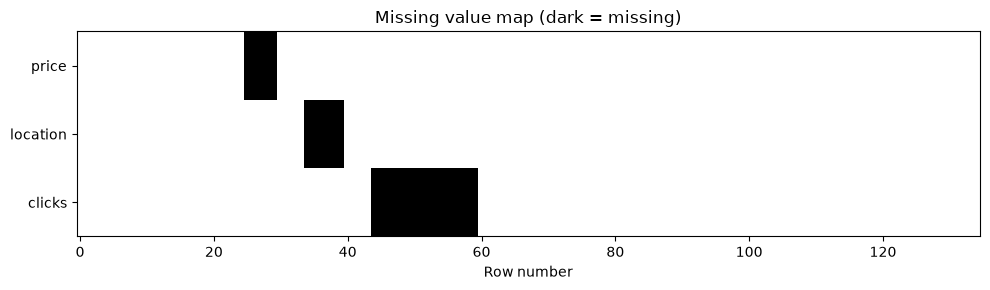

In [20]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(more[["price", "location", "clicks"]].isna().T, aspect="auto", cmap="gray_r", interpolation="nearest")
ax.set_yticks(range(3), ["price", "location", "clicks"])
ax.set_xlabel("Row number")
ax.set_title("Missing value map (dark = missing)")
plt.tight_layout()
plt.show()

Read this map before you impute anything.

- Gaps **scattered** across rows with no relationship between columns is consistent with MCAR.
- Gaps that **line up vertically** across several columns suggest whole records failed together, which points at an ingestion or delivery fault rather than a measurement fault.
- Gaps concentrated in **one contiguous stretch** of rows usually means an outage, and the fix is to re-fetch that window rather than to invent values for it.

If you prefer a purpose built tool for this, [`missingno`](https://github.com/ResidentMario/missingno) draws richer versions of this chart, including a nullity **correlation** heatmap that shows which columns tend to go missing together. That heatmap is the fastest way to spot the vertical-stripe pattern described above. The plain matplotlib version here is enough to make the decision, and it costs you no extra dependency.

---
# Part 3: Stop guessing, start scoring

Here is the part that most imputation tutorials skip.

Every method you are about to try produces numbers. All of them look equally plausible in a dataframe. The only way to know which is better is to compare against values you already know.

You have that luxury here. For each file with holes in it, there is an original file with the values intact. That lets you build a scoring harness.

The metric is **RMSE**, root mean squared error. Compute the difference between the imputed value and the true value, square it, average over the positions that were missing, and take the square root. Lower is better, and a perfect imputation scores zero.

The crucial detail: score **only the positions that were actually missing**. Including the untouched values would flood the score with thousands of zero errors and make every method look excellent.

In [21]:
def rmse(truth, imputed, missing_mask):
    """RMSE between imputed and true values, computed only where data was missing."""
    truth = np.asarray(truth, dtype=float)
    imputed = np.asarray(imputed, dtype=float)
    errors = truth[missing_mask] - imputed[missing_mask]
    return float(np.sqrt(np.mean(errors ** 2)))

Now load the CO2 pair: the original, and the version with the holes already exposed as `NaN`.

In [22]:
co2_truth = pd.read_csv(DATA_DIR / "co2_original.csv")
co2_gaps = pd.read_csv(DATA_DIR / "co2_missing_only.csv")

co2_mask = co2_gaps["co2"].isna().to_numpy()
print("Missing values to impute:", co2_mask.sum(), "out of", len(co2_gaps))

Missing values to impute: 35 out of 226


Thirty five gaps out of 226 rows. Look at the series before choosing a strategy.

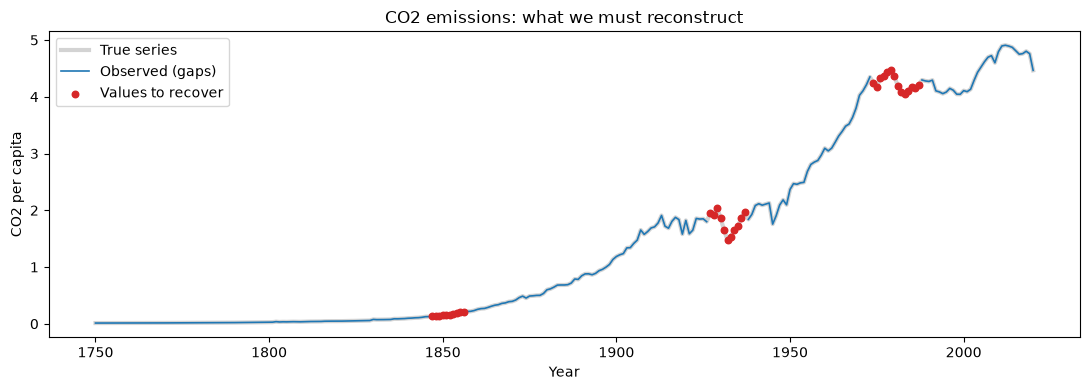

In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(co2_truth["year"], co2_truth["co2"], color="lightgray", lw=3, label="True series")
ax.plot(co2_gaps["year"], co2_gaps["co2"], color="tab:blue", lw=1.2, label="Observed (gaps)")
ax.scatter(co2_truth.loc[co2_mask, "year"], co2_truth.loc[co2_mask, "co2"],
           color="tab:red", s=22, zorder=3, label="Values to recover")
ax.set_xlabel("Year")
ax.set_ylabel("CO2 per capita")
ax.set_title("CO2 emissions: what we must reconstruct")
ax.legend()
plt.tight_layout()
plt.show()

This series has an obvious property: it **trends**. Values rise over time, and any given year looks very much like the year before it.

Hold that thought. It is going to decide which method wins.

---
# Part 4: Univariate imputation, the baseline

Univariate methods look only at the column being filled. They ignore every other column and ignore position in the series.

Start with the two everyone reaches for first.

In [24]:
co2_mean = co2_gaps["co2"].fillna(co2_gaps["co2"].mean())
co2_median = co2_gaps["co2"].fillna(co2_gaps["co2"].median())

print("mean   RMSE:", round(rmse(co2_truth["co2"], co2_mean, co2_mask), 4))
print("median RMSE:", round(rmse(co2_truth["co2"], co2_median, co2_mask), 4))

mean   RMSE: 1.8185
median RMSE: 2.0403


Keep those numbers. Now see what they actually did to the series.

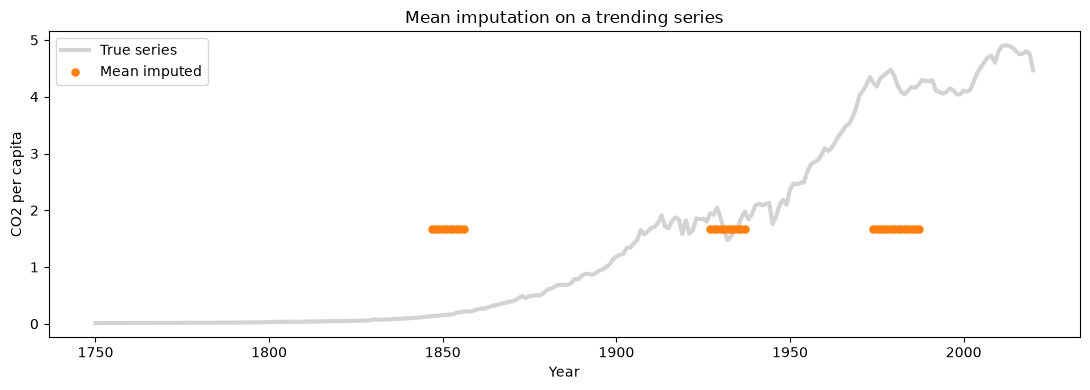

In [25]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(co2_truth["year"], co2_truth["co2"], color="lightgray", lw=3, label="True series")
ax.scatter(co2_truth.loc[co2_mask, "year"], co2_mean[co2_mask],
           color="tab:orange", s=26, zorder=3, label="Mean imputed")
ax.set_xlabel("Year")
ax.set_ylabel("CO2 per capita")
ax.set_title("Mean imputation on a trending series")
ax.legend()
plt.tight_layout()
plt.show()

The problem is visible without any statistics.

Mean imputation places every filled value on one flat horizontal line, because the mean is a single number. On a series that climbs steadily, that line is far too high for the early years and far too low for the late ones. The imputed points do not sit on the curve. They sit across it.

Mean imputation discarded the single most useful piece of information in the dataset: **where in the series the gap occurred**.

## Carrying values forward

The next step up is to use position. Forward fill carries the last observed value into the gap, and backward fill pulls the next one back.

In [26]:
co2_ffill = co2_gaps["co2"].ffill()
co2_bfill = co2_gaps["co2"].bfill()

print("ffill RMSE:", round(rmse(co2_truth["co2"], co2_ffill, co2_mask), 4))
print("bfill RMSE:", round(rmse(co2_truth["co2"], co2_bfill, co2_mask), 4))

ffill RMSE: 0.1492
bfill RMSE: 0.141


An enormous improvement over the mean, from a method that is barely more sophisticated.

That is the lesson in miniature: the gain came from **using temporal position**, not from using a cleverer algorithm.

One caution on forward fill. It is the right default for step like data that genuinely holds its value between readings, such as a daily account balance or a configuration setting. On a smoothly varying measurement it creates small flat plateaus that are not physically real. It is cheap and safe, but it is not the best you can do.

---
# Part 5: Time aware interpolation

Interpolation fills a gap by fitting a line or curve **through the surrounding points**, so the filled value depends on both neighbours rather than just one.

One thing to know before you read the scores. `method="linear"` in pandas is *position* aware, not *time* aware: it treats rows as equally spaced and ignores what the index actually says. That is fine here, because the CO2 file has exactly one row per year with no years skipped. The moment your rows are irregularly spaced (hourly readings where some hours never arrived, or trading days that skip weekends) you want `method="time"` or `method="index"`, which use the real distance between points. Challenge 2 asks you to try them.

The full list of methods, and which ones need a `DatetimeIndex`, is in the [`Series.interpolate` documentation](https://pandas.pydata.org/docs/reference/api/pandas.Series.interpolate.html).

In [27]:
co2_linear = co2_gaps["co2"].interpolate(method="linear")
print("linear interpolation RMSE:", round(rmse(co2_truth["co2"], co2_linear, co2_mask), 4))

linear interpolation RMSE: 0.1399


In [28]:
co2_nearest = co2_gaps["co2"].interpolate(method="nearest")
co2_poly = co2_gaps["co2"].interpolate(method="polynomial", order=2)
co2_spline = co2_gaps["co2"].interpolate(method="spline", order=3)

print("nearest        RMSE:", round(rmse(co2_truth["co2"], co2_nearest, co2_mask), 4))
print("polynomial (2) RMSE:", round(rmse(co2_truth["co2"], co2_poly, co2_mask), 4))
print("spline (3)     RMSE:", round(rmse(co2_truth["co2"], co2_spline, co2_mask), 4))

nearest        RMSE: 0.1368
polynomial (2) RMSE: 0.2129
spline (3)     RMSE: 0.4284


Two things to read here.

First, `nearest` and `linear` land within a couple of percent of each other. That difference is far too small to declare a winner, and treating it as one would be reading noise. What matters is that both sit in a completely different league from the mean, which the summary table below makes obvious.

Second, the higher order curves are **worse** than the straight line, and not marginally: the cubic spline is about three times the error of the linear fit.

The reason is the shape of the holes in this file. Measure them.

In [29]:
gap_runs = co2_gaps["co2"].isna().groupby(co2_gaps["co2"].notna().cumsum()).sum()
print("Gap widths, in consecutive years:", sorted(gap_runs[gap_runs > 0].tolist()))

Gap widths, in consecutive years: [10, 11, 14]


Three holes, each 10 to 14 years wide. That is a long way to travel with no anchor points in between.

A straight line crossing a 14 year hole can only be wrong in one direction, and only by so much. A cubic spline crossing the same hole is free to curve, and with nothing inside the gap to constrain it, it curves away from the truth and swings back. This is the same overshoot that makes high-degree polynomial fits notorious, known as [Runge's phenomenon](https://en.wikipedia.org/wiki/Runge%27s_phenomenon).

Complexity is not the same thing as accuracy. A flexible method needs data to be flexible *against*, and inside a gap there is none by definition.

## The full comparison

In [30]:
co2_results = pd.DataFrame({
    "method": ["mean", "median", "ffill", "bfill", "nearest", "linear", "polynomial(2)", "spline(3)"],
    "family": ["univariate", "univariate", "positional", "positional",
               "interpolation", "interpolation", "interpolation", "interpolation"],
    "rmse": [
        rmse(co2_truth["co2"], co2_mean, co2_mask),
        rmse(co2_truth["co2"], co2_median, co2_mask),
        rmse(co2_truth["co2"], co2_ffill, co2_mask),
        rmse(co2_truth["co2"], co2_bfill, co2_mask),
        rmse(co2_truth["co2"], co2_nearest, co2_mask),
        rmse(co2_truth["co2"], co2_linear, co2_mask),
        rmse(co2_truth["co2"], co2_poly, co2_mask),
        rmse(co2_truth["co2"], co2_spline, co2_mask),
    ],
}).sort_values("rmse").reset_index(drop=True)

co2_results.round(4)

,method,family,rmse
0,nearest,interpolation,0.1368
1,linear,interpolation,0.1399
2,bfill,positional,0.1410
3,ffill,positional,0.1492
4,polynomial(2),interpolation,0.2129
5,spline(3),interpolation,0.4284
6,mean,univariate,1.8185
7,median,univariate,2.0403


In [31]:
best = co2_results.iloc[0]
worst = co2_results.iloc[-1]
print(f"Best : {best['method']} at RMSE {best['rmse']:.4f}")
print(f"Worst: {worst['method']} at RMSE {worst['rmse']:.4f}")
print(f"The worst method is {worst['rmse'] / best['rmse']:.1f}x less accurate than the best.")

Best : nearest at RMSE 0.1368
Worst: median at RMSE 2.0403
The worst method is 14.9x less accurate than the best.


Read this table as three tiers, not eight rankings. Everything that uses neighbours (`nearest`, `linear`, `bfill`, `ffill`) clusters around 0.14. The higher order curves sit a tier above at roughly 0.21 to 0.43. Mean and median sit in a different world entirely, near 1.8 to 2.0.

That is a **fifteen fold** spread between the best and worst choice, on the same data, with no model training and no tuning anywhere. The single decision that bought almost all of it was "use the neighbours at all", and it was free.

Why did the position aware methods dominate so completely? Because of a measurable property of this series.

In [32]:
print("Lag-1 autocorrelation of the CO2 series:", round(co2_truth["co2"].autocorr(1), 4))

Lag-1 autocorrelation of the CO2 series: 0.9988


An autocorrelation of essentially 1.0 means each value is almost perfectly predicted by the one before it. All of the information needed to fill a gap is sitting in the immediate neighbours.

Any method that uses neighbours wins. Any method that ignores them loses. That is the whole story on this dataset, and you can see it in a single number before you impute anything.

**Go deeper:** [`Series.autocorr`](https://pandas.pydata.org/docs/reference/api/pandas.Series.autocorr.html) is just Pearson correlation between the series and a shifted copy of itself. `statsmodels` will plot the [whole autocorrelation function](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html) at once, which tells you how far back the useful structure reaches instead of only one lag. For why this matters generally, [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/acf.html) is free online and is the standard reference.

## Seeing it, not just scoring it

The RMSE numbers above only exist because this is a teaching dataset: you have the original file, with values removed on purpose, so you know the exact right answer for every gap. In production you almost never get that. Nobody deletes good data on purpose just so you can check yourself later, so there is usually no ground truth to score against.

What you always have is your own eyes. Plot the repaired series next to the true one and ask whether it looks like something that could plausibly have happened. The goal was never a perfect RMSE. Real data is noisy, so a repair that is a *good representation* of what the value probably was is the actual bar, not an exact match to four decimal places.

Look at four of the methods above side by side against the truth.

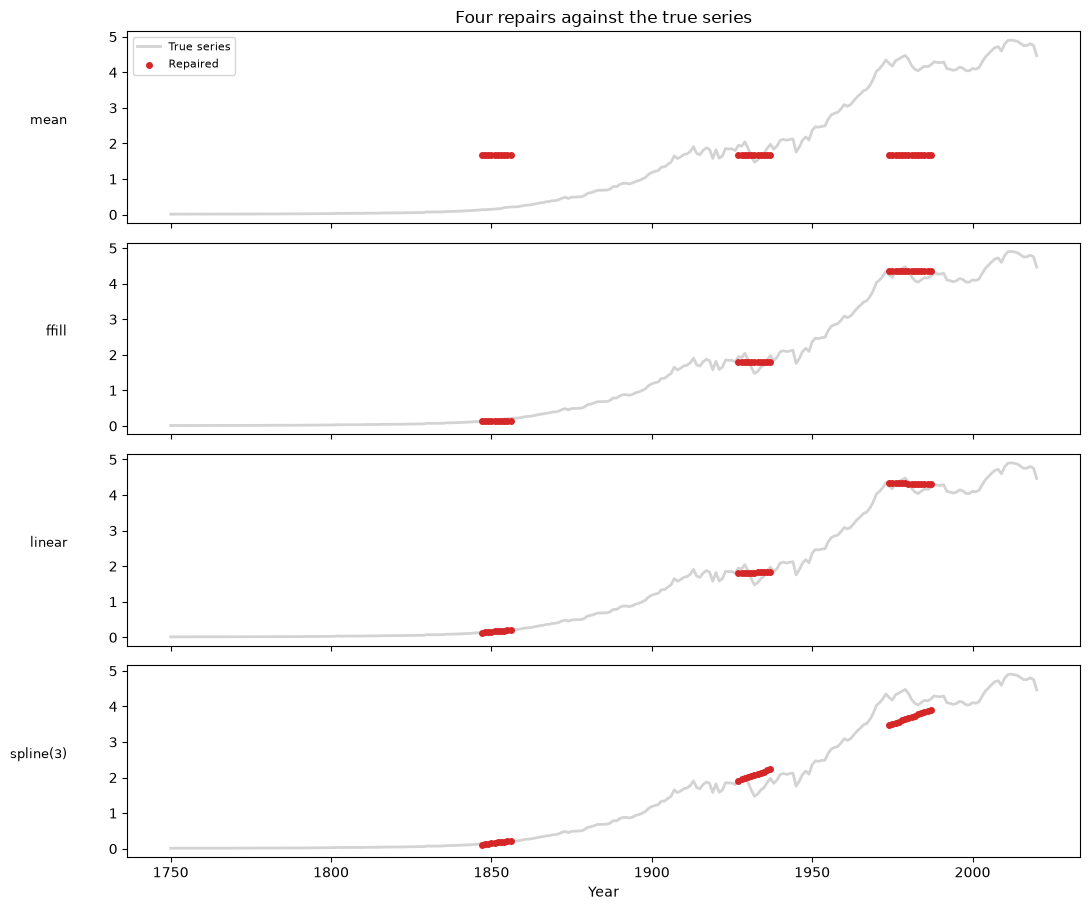

In [33]:
def plot_repairs(x, truth, repairs, mask, title):
    """Small multiples: true series in gray, each method's repaired values marked at the positions that were missing."""
    fig, axes = plt.subplots(len(repairs), 1, figsize=(11, 2.3 * len(repairs)), sharex=True)
    for ax, (name, values) in zip(axes, repairs.items()):
        ax.plot(x, truth, color="lightgray", lw=2, label="True series")
        ax.scatter(x[mask], np.asarray(values)[mask], color="tab:red", s=16, zorder=3, label="Repaired")
        ax.set_ylabel(name, rotation=0, ha="right", labelpad=30, fontsize=9)
    axes[0].legend(loc="upper left", fontsize=8)
    axes[0].set_title(title)
    axes[-1].set_xlabel("Year")
    plt.tight_layout()
    plt.show()


plot_repairs(
    co2_truth["year"].to_numpy(),
    co2_truth["co2"].to_numpy(),
    {"mean": co2_mean, "ffill": co2_ffill, "linear": co2_linear, "spline(3)": co2_spline},
    co2_mask,
    "Four repairs against the true series",
)

Mean sits on a flat line that misses the trend everywhere, exactly as the earlier chart already showed. `ffill` visibly steps, since it repeats the last known value until the next real reading arrives. `linear` sits almost on top of the true series across every gap. `spline(3)` tracks well too, except where it swings away from the truth across the widest gaps, which is the overshoot the RMSE table was already warning you about.

The picture and the RMSE table agree here, and that will not always happen. When they disagree, trust the picture for whether a repair is even usable, and trust the RMSE, when you have it, to rank precision between repairs that already look plausible.

## Does interpolation help everywhere?

Interpolation won decisively on CO2 because the series is almost perfectly autocorrelated: each year predicts the next. Does that make interpolation a better family of methods in general, or did it just win on data built for it to win on? Test it on a series where neighbours are not informative.


In [34]:
clicks_truth = pd.read_csv(DATA_DIR / "clicks_original.csv")
clicks_gaps = pd.read_csv(DATA_DIR / "clicks_missing_more.csv")
clicks_mask = clicks_gaps["clicks"].isna().to_numpy()

clicks_mean = clicks_gaps["clicks"].fillna(clicks_gaps["clicks"].mean())
clicks_linear = clicks_gaps["clicks"].interpolate(method="linear")
clicks_nearest = clicks_gaps["clicks"].interpolate(method="nearest")
clicks_poly = clicks_gaps["clicks"].interpolate(method="polynomial", order=2)

interp_on_clicks = pd.DataFrame({
    "method": ["mean", "linear", "nearest", "polynomial(2)"],
    "rmse": [
        rmse(clicks_truth["clicks"], clicks_mean, clicks_mask),
        rmse(clicks_truth["clicks"], clicks_linear, clicks_mask),
        rmse(clicks_truth["clicks"], clicks_nearest, clicks_mask),
        rmse(clicks_truth["clicks"], clicks_poly, clicks_mask),
    ],
}).sort_values("rmse").reset_index(drop=True)

interp_on_clicks


,method,rmse
0,mean,2898.230938
1,linear,3860.816866
2,nearest,4956.020644
3,polynomial(2),15176.211444


In [35]:
print("clicks lag-1 autocorrelation:", round(clicks_truth["clicks"].autocorr(1), 4))


clicks lag-1 autocorrelation: 0.2229


Mean wins here, and the higher order method is not close. Interpolation actively hurt this series.

The reason is the autocorrelation you just printed. CO2 sits at essentially 1.0. `clicks` is far lower, so a neighbouring value is only weakly related to the gap next to it. Interpolation assumes the neighbour is informative. When that assumption is false, drawing a line through the neighbours is worse than reporting one stable number for every gap.

Hold onto this result. Part 7 finds the same pattern again from a different angle, with a different method family and a different reason to check before you trust sophistication.


---
# Part 6: Multivariate imputation with machine learning

Everything so far used one column. Multivariate methods use the **other columns** to inform the estimate, and this is where actual ML models enter.

Two from scikit-learn:

- **`KNNImputer`** finds the *k* rows most similar to the row with the gap, based on the columns that are present, then averages their values for the missing column.
- **`IterativeImputer`** treats the column with gaps as a regression target, predicts it from the other columns, and cycles through the columns repeatedly until the estimates stabilise. This is the approach known in the statistics literature as MICE.

Both are documented in scikit-learn's [imputation user guide](https://scikit-learn.org/stable/modules/impute.html), which also has a [worked comparison of imputers on real datasets](https://scikit-learn.org/stable/auto_examples/impute/plot_iterative_imputer_variants_comparison.html) worth reading after this activity. MICE itself comes from [van Buuren and Groothuis-Oudshoorn (2011)](https://doi.org/10.18637/jss.v045.i03), the paper behind the R `mice` package that `IterativeImputer` is modelled on.

Switch to the clickstream dataset, which has three numeric columns and gaps in all of them.

In [36]:
# clicks_truth and clicks_gaps are already loaded from Part 5.
# The mask is 2D now (one column per feature), because these imputers fill every column at once.
FEATURES = ["price", "location", "clicks"]
clicks_mask = clicks_gaps[FEATURES].isna().to_numpy()
print("Missing cells to impute:", clicks_mask.sum())

Missing cells to impute: 27


In [37]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

`IterativeImputer` is still marked experimental in scikit-learn, so importing `enable_iterative_imputer` first is required. Without that line the import raises `ImportError`, and the message tells you exactly which line to add. This has been true for several years now, so treat it as a permanent quirk rather than something about to change.

Establish the baseline first. Always establish the baseline first.

In [38]:
X = clicks_gaps[FEATURES].astype(float)

imputed_mean = SimpleImputer(strategy="mean").fit_transform(X)
imputed_median = SimpleImputer(strategy="median").fit_transform(X)

Now the ML based imputers.

`IterativeImputer` will very likely print a `ConvergenceWarning` saying the early stopping criterion was not reached. That is expected here and not an error: the imputer ran all 20 rounds without the estimates settling down, which is exactly what happens when the columns carry no real signal about each other. Part 7 explains why that is the case for this dataset. Read the warning as information, not as a failure.

In [39]:
imputed_knn5 = KNNImputer(n_neighbors=5).fit_transform(X)
imputed_iterative = IterativeImputer(random_state=0, max_iter=20).fit_transform(X)

Score them per column, since the columns are on completely different scales and a single combined number would be meaningless.

In [40]:
def score_all_columns(imputed_array):
    return {
        col: rmse(clicks_truth[col], imputed_array[:, i], clicks_mask[:, i])
        for i, col in enumerate(FEATURES)
    }


clicks_results = pd.DataFrame({
    "mean": score_all_columns(imputed_mean),
    "median": score_all_columns(imputed_median),
    "KNN (k=5)": score_all_columns(imputed_knn5),
    "IterativeImputer": score_all_columns(imputed_iterative),
}).T

clicks_results.round(4)

,price,location,clicks
mean,0.9003,1.4495,2898.2309
median,0.9082,1.7321,2786.6833
KNN (k=5),0.9846,1.5916,3079.4596
IterativeImputer,0.8906,1.4577,2736.4606


---
# Part 7: The result that contradicts the textbook

Look carefully at the `clicks` column.

`KNNImputer`, the sophisticated ML method, performed **worse than the mean**. Not marginally worse. Worse.

`IterativeImputer` edged out the mean, but by a small margin that would not survive a different random split.

If you have read the usual advice on imputation, this is not what you were promised. So find out why rather than assuming the code is wrong.

In [41]:
clicks_truth[FEATURES].corr().round(3)

,price,location,clicks
price,1.000,0.011,-0.128
location,0.011,1.000,-0.146
clicks,-0.128,-0.146,1.000


There is the explanation.

The strongest correlation with `clicks` is about `-0.15`, and the correlation between `price` and `location` is about `0.01`. For context, a correlation that weak means `price` explains under 2 percent of the variation in `clicks` (square the correlation to get that share).

`price` and `location` tell you essentially nothing about `clicks`.

Now recall what `KNNImputer` actually does. It locates the rows most similar to yours **using the other columns**, and averages their values. When those other columns carry no information about the target, "most similar" is meaningless. The algorithm is averaging a small, arbitrarily chosen subset of rows.

That is strictly worse than averaging all of them, which is exactly what mean imputation does. A noisy average of 5 arbitrary rows loses to a stable average of all 119 observed ones.

**KNN imputation is not better than the mean. It is better than the mean when the features are correlated.** On this dataset that condition does not hold, so the method has nothing to work with.

See the noise directly rather than just the RMSE column. Plot the true `clicks` values against what each method filled in, at only the positions that were actually missing. A perfect method would put every point on the diagonal.

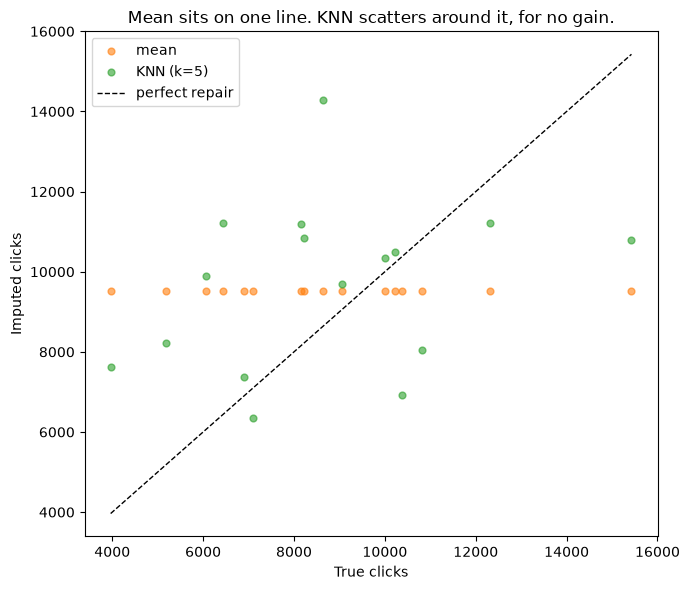

In [42]:
clicks_col = FEATURES.index("clicks")
clicks_missing_mask = clicks_mask[:, clicks_col]
true_clicks = clicks_truth.loc[clicks_missing_mask, "clicks"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(true_clicks, imputed_mean[clicks_missing_mask, clicks_col],
           color="tab:orange", alpha=0.6, s=24, label="mean")
ax.scatter(true_clicks, imputed_knn5[clicks_missing_mask, clicks_col],
           color="tab:green", alpha=0.6, s=24, label="KNN (k=5)")
limits = [true_clicks.min(), true_clicks.max()]
ax.plot(limits, limits, color="black", lw=1, ls="--", label="perfect repair")
ax.set_xlabel("True clicks")
ax.set_ylabel("Imputed clicks")
ax.set_title("Mean sits on one line. KNN scatters around it, for no gain.")
ax.legend()
plt.tight_layout()
plt.show()

The mean's points sit in a tight horizontal band, because it always guesses the same number regardless of what the true value turned out to be. KNN's points scatter more widely around that band, sometimes closer to the diagonal, sometimes further, because it is echoing whichever five arbitrary rows happened to be its nearest neighbours on features that carry no information about `clicks`. Neither cloud hugs the diagonal the way the CO2 repairs did, because there is no signal here for any method to find. The picture matches the RMSE table: KNN is not wrong everywhere, it is just as likely to land further from the truth as closer to it, and that unpredictability is the cost of asking a method to use columns that have nothing to offer.

Nor is there much temporal structure to fall back on. The lag-1 autocorrelation you measured in Part 5 was about 0.22, against 0.9988 for the CO2 series.

This dataset simply has weak structure in both directions, and no imputation method can manufacture information that is not present. When the data has nothing to offer, the simple, stable choice is the right one.

### What to take from this

The lesson is not "KNN is bad". The lesson is the method:

1. **Check for structure before choosing a method.** A correlation matrix and an autocorrelation take one line each and tell you which family of methods can possibly help.
2. **Always compute the trivial baseline.** Mean imputation costs nothing and is the number every sophisticated method must beat.
3. **Measure rather than assume.** You had ground truth here. When you do not, hold out known values, remove them deliberately, and score against those.
4. **Sophistication that is not measured is just cost.** A tuned `IterativeImputer` in a nightly pipeline is compute, latency, and a dependency. If it does not beat `.fillna(mean)`, it is buying you nothing.

Being able to say "we measured it and the simple method won" is a stronger engineering position than deploying the impressive one.

---
# Part 8: Does the regressor inside `IterativeImputer` matter?

`IterativeImputer` needs a regression model to predict each missing column from the others. Part 6 used the default, `BayesianRidge`. Scikit-learn lets you swap in any regressor as the `estimator` argument, including ones with very different assumptions:

- **`LinearRegression`** and **`ElasticNet`**: linear models, similar in spirit to `BayesianRidge`.
- **`ExtraTreesRegressor`** and **`BaggingRegressor`**: ensembles of decision trees, flexible enough to fit non-linear relationships.
- **`KNeighborsRegressor`**: predicts from the average of the nearest neighbours in feature space, the same idea `KNNImputer` used directly in Part 6, but here used as the model inside the iterative loop.

Any scikit-learn regressor works here, so the [estimator API](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model) is your menu. Scikit-learn maintains a [side-by-side comparison of `IterativeImputer` variants](https://scikit-learn.org/stable/auto_examples/impute/plot_iterative_imputer_variants_comparison.html) on the California housing data, where the columns genuinely are correlated; running that example after this one is the cleanest way to see the same code produce the opposite conclusion on better-behaved data.

Form an expectation before you run anything. You already know `price` and `location` carry almost no information about `clicks`. Do you expect a more flexible regressor to rescue that, or to make it worse?


In [43]:
from sklearn.ensemble import ExtraTreesRegressor, BaggingRegressor
from sklearn.linear_model import BayesianRidge, ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor


In [44]:
regressors = {
    "BayesianRidge (default)": BayesianRidge(),
    "LinearRegression": LinearRegression(),
    "ElasticNet": ElasticNet(),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=50, random_state=0),
    "Bagging": BaggingRegressor(n_estimators=50, random_state=0),
    "KNeighborsRegressor": KNeighborsRegressor(n_neighbors=3),
}

clicks_col = FEATURES.index("clicks")

regressor_results = pd.DataFrame({
    "regressor": list(regressors.keys()),
    "rmse": [
        rmse(
            clicks_truth["clicks"],
            IterativeImputer(estimator=reg, random_state=0, max_iter=20).fit_transform(X)[:, clicks_col],
            clicks_mask[:, clicks_col],
        )
        for reg in regressors.values()
    ],
}).sort_values("rmse").reset_index(drop=True)

regressor_results


/Users/tarekatwan/Repos/MyWork/Teach/repos/TechCatalyst_DE_2026/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/tarekatwan/Repos/MyWork/Teach/repos/TechCatalyst_DE_2026/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/tarekatwan/Repos/MyWork/Teach/repos/TechCatalyst_DE_2026/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,regressor,rmse
0,BayesianRidge (default),2736.460572
1,ElasticNet,2738.972227
2,LinearRegression,2743.916948
3,KNeighborsRegressor,3373.304863
4,ExtraTrees,3535.505614
5,Bagging,3606.739220


The linear-family regressors (`BayesianRidge`, `LinearRegression`, `ElasticNet`) land close together and edge out the mean by a small margin. The tree-based and neighbour-based regressors score worse than the mean, some considerably worse.

This is not a fluke of one run. `ExtraTreesRegressor`, `BaggingRegressor`, and `KNeighborsRegressor` are all more flexible than a straight line. Flexibility only helps when there is a real relationship to fit. Here the relationship between `price` and `location` and `clicks` is close to nothing, so the flexible models fit noise instead: the same failure mode that sank `KNNImputer` in Part 7.

The takeaway is specific, not general. Swapping in a more powerful looking estimator is not automatically an improvement. `IterativeImputer` inherits whatever its chosen regressor is good and bad at, so check the estimator the same way you already learned to check the imputer.


## Choosing a strategy

| Situation | Start with | Why |
| :--- | :--- | :--- |
| Strong temporal structure (high autocorrelation) | Linear interpolation | Neighbours in time carry the information |
| Step like series (balances, config, status) | Forward fill | The value genuinely persists until it changes |
| Correlated feature columns | `IterativeImputer`, with a regressor matched to the relationship | Other columns can genuinely predict the gap, but only if the estimator fits how they actually relate; a flexible estimator on a weak relationship just fits noise |
| Weak or no structure | Mean or median | Stable, cheap, and nothing else can beat it |
| Categorical column | Mode, or an explicit "Unknown" level | "Unknown" is often real signal worth keeping |
| Suspected MNAR | Do not impute | Flag the rows and escalate upstream |

One habit worth carrying into production regardless of method: **add a boolean column recording that a value was imputed**. It costs one bit per row and it preserves the distinction between measured and estimated all the way downstream, where somebody will eventually need it.

In [45]:
clicks_final = clicks_gaps.copy()
clicks_final["clicks_was_imputed"] = clicks_final["clicks"].isna()
clicks_final["clicks"] = clicks_final["clicks"].fillna(clicks_final["clicks"].mean())

clicks_final.loc[clicks_final["clicks_was_imputed"], ["date", "clicks", "clicks_was_imputed"]].head()

,date,clicks,clicks_was_imputed
44,5/15/08,9530.336134,True
45,5/16/08,9530.336134,True
46,5/17/08,9530.336134,True
47,5/18/08,9530.336134,True
48,5/19/08,9530.336134,True


---
# Your Turn

You have been shown the method. Now apply it yourself.

Work in your own copy of this notebook under `student-work/week6/day2/`. Do not edit the file in the course folder, because that will conflict the next time you pull.

Each challenge below has a starter cell with one or more `____` blanks. Fill them in, run the cell, and answer the markdown question underneath it. Use the hints if you get stuck.


## Challenge 1: Audit a file you have not seen

`clicks_missing_multiple.csv` mixes several of the four faces of missing data from Part 1. Write a general-purpose auditor, one that would work correctly on any file, including one with no numeric sentinel at all, not just this one.

Complete `audit_missing()` below so that, for every column, it reports:

- the count `.isna()` already catches
- the count of string placeholders that are not real nulls (values that fail `pd.to_numeric` but were not already null)
- the count of suspicious numeric sentinels (an implausible value, such as an exact `0`, repeated often enough to look like a placeholder rather than real data)
- your best estimate of the true missing count, the sum of the three


In [ ]:
def audit_missing(path):
    df = pd.read_csv(path)
    rows = []
    for col in df.columns:
        isna_count = ____

        placeholder_count = ____

        sentinel_count = ____

        rows.append({
            "column": col,
            "isna": isna_count,
            "placeholder": placeholder_count,
            "sentinel": sentinel_count,
            "best_estimate": isna_count + placeholder_count + sentinel_count,
        })
    return pd.DataFrame(rows).set_index("column")


audit_missing(DATA_DIR / "clicks_missing_multiple.csv")


In a markdown cell, state which of the four faces this file actually contains, and by how much the naive `.isna()` count undercounts the true total.


<details>
<summary>Hint 1: the isna and placeholder counts</summary>

`isna_count` is exactly the one-liner from Part 1: `df[col].isna().sum()`.

For `placeholder_count`, reuse the Part 1 pattern column by column:

```python
not_numeric = pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
placeholder_count = not_numeric.sum()
```

This only makes sense for columns that are supposed to be numeric. A text column like `date` will flag every row as "not numeric", which is not useful. Guard it, for example by skipping the placeholder and sentinel checks for a column where almost every value fails the conversion.

</details>

<details>
<summary>Hint 2: the sentinel count</summary>

There is no generic formula for "suspicious sentinel", because it depends on domain knowledge, the same way spotting the CO2 zeros in Part 1 did. A defensible approach: convert the column to numeric first (coercing placeholders to `NaN`), then flag a value as a candidate sentinel only if it is implausible for that column (for example, exactly `0` in a column where `0` cannot be a real reading) and appears more than once.

It is fine, and correct, for `sentinel_count` to come out as `0` for a column that has no sentinel. Report the true number, do not force one.

</details>


## Challenge 2: Beat the baseline, or prove you cannot

Using `co2_missing_only.csv` and the `rmse()` helper from Part 3, add at least three strategies beyond the mean baseline, including one method not demonstrated in Part 4 or Part 5.


In [ ]:
co2_baseline = co2_gaps["co2"].fillna(co2_gaps["co2"].mean())

candidate_methods = {
    "mean": co2_baseline,
    # TODO: add at least three more strategies here, including one not
    # demonstrated in Part 4 or Part 5. "time", "pchip", and "akima" are
    # all valid arguments to .interpolate(method=...).
}

challenge2_results = pd.DataFrame({
    "method": list(candidate_methods.keys()),
    "rmse": [rmse(co2_truth["co2"], values, co2_mask) for values in candidate_methods.values()],
}).sort_values("rmse").reset_index(drop=True)

challenge2_results


In a markdown cell, state which method you would ship and why. If nothing beats the baseline, say so; that is a legitimate finding, and reporting it accurately is the point.


<details>
<summary>Hint 1: methods that need a real datetime index</summary>

`method="time"` interpolates using elapsed time, not row position, so it needs a `DatetimeIndex`. Build one before calling it:

```python
co2_by_year = co2_gaps.set_index(pd.to_datetime(co2_gaps["year"], format="%Y"))
co2_by_year["co2"].interpolate(method="time")
```

`method="index"` gives a similar result using the numeric `year` column directly as the index, no datetime conversion required.

</details>

<details>
<summary>Hint 2: pchip and akima</summary>

Both are one-line swaps for the `method` argument you already used in Part 5: `co2_gaps["co2"].interpolate(method="pchip")`. They come from `scipy`, already a dependency of this project, so no extra install is needed.

</details>


## Challenge 3: Build the evidence for a real decision

You will not always have the original file. Simulate the situation where you do not: remove 15 percent of the `clicks` values yourself, score against the positions you removed, and repeat with three different random seeds.


In [ ]:
def make_gap(series, frac, random_state):
    """Remove `frac` of the values in `series` at random.

    Returns the gapped series and a boolean mask marking which positions were
    removed, so you can score against them later.
    """
    rng = np.random.default_rng(random_state)
    n_missing = int(len(series) * frac)
    removed = ____  # TODO: pick n_missing distinct positions with rng.choice(...)

    mask = np.zeros(len(series), dtype=bool)
    mask[removed] = True

    gapped = series.copy()
    gapped.iloc[removed] = np.nan
    return gapped, mask


def score_strategies(gapped, truth, mask):
    strategies = {
        "mean": gapped.fillna(gapped.mean()),
        "ffill": gapped.ffill(),
        # TODO: add at least two more strategies here. Reuse .interpolate(),
        # or a scikit-learn imputer from Part 6 if you reshape the column into
        # the 2D array it expects.
    }
    return {name: rmse(truth, values, mask) for name, values in strategies.items()}


clicks_full = pd.read_csv(DATA_DIR / "clicks_original.csv")

results_by_seed = {}
for seed in [0, 1, 2]:
    gapped, mask = make_gap(clicks_full["clicks"], frac=0.15, random_state=seed)
    results_by_seed[seed] = score_strategies(gapped, clicks_full["clicks"], mask)

pd.DataFrame(results_by_seed)


In a markdown cell, answer: did the winning method stay the same across all three seeds? If it changed, what does that tell you about the size of the difference between those methods, and would you still be comfortable claiming one is better?


<details>
<summary>Hint 1: picking random positions without replacement</summary>

`rng.choice(len(series), size=n_missing, replace=False)` draws `n_missing` distinct integer positions from `0` to `len(series) - 1`. Those are the row positions to null out with `.iloc[...]`, and the same positions become your scoring mask.

</details>

<details>
<summary>Hint 2: a single column has no other column to lean on</summary>

`clicks` on its own is one column. A multivariate method such as `KNNImputer` needs feature columns to compare rows against; with only one column there is nothing for it to condition on, so it collapses toward the univariate case. It is worth trying anyway, but do not expect it to look like Part 6's results, and be ready to explain why in your write-up.

</details>


## Challenge 4: Make the case in writing

Write a short markdown cell, no more than 150 words, aimed at a data engineering lead who has to approve your change. State which strategy you are proposing for the clickstream pipeline, the evidence supporting it, and the one condition that would make you revisit the decision.

Write it as something you would defend in a design review, not as a lab summary. Start from this template and replace every `[...]`:

```markdown
**Proposed strategy:** [...]

**Evidence:** [...]

**Condition that would make me revisit this:** [...]
```


---
## What you did

- Identified all four ways missing data appears, including the two `.isna()` cannot see.
- Established that a null count is not a data quality check.
- Classified missingness as MCAR, MAR, or MNAR, and connected each to a different response.
- Built a scoring harness and measured every strategy against ground truth.
- Found that interpolation beat mean imputation by roughly 13x on a strongly autocorrelated series.
- Found that ML based KNN imputation **lost** to the mean on a weakly correlated one, and explained precisely why.
- Found that interpolation, the star of Part 5, lost to the mean on a series with almost no autocorrelation, the same lesson from a different angle.
- Found that the regressor chosen inside `IterativeImputer` mattered as much as the choice of imputer family, and that a more flexible regressor made things worse on weakly correlated data.

Next: **Activity 2**, where you take the same measure rather than assume discipline into outlier detection, and find that the definition of "outlier" is much less obvious than it first appears.

---
## Go deeper

You measured a lot today. These are the places to go if you want the theory behind the measurements, or the tools that industrialise them.

### The concepts

| Resource | Why it is worth your time |
| :--- | :--- |
| [pandas: working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html) | The definitive statement of what pandas counts as null and what it does not. Read the section on the difference between `NaN`, `NaT`, and `pd.NA`. |
| [van Buuren, *Flexible Imputation of Missing Data*](https://stefvanbuuren.name/fimd/) | The standard book on imputation, free online. Chapter 1 alone will change how you write incident reports about missing data. |
| [scikit-learn: imputation of missing values](https://scikit-learn.org/stable/modules/impute.html) | The user guide for everything in Parts 6 and 8, including `MissingIndicator`, which automates the "was imputed" flag you added by hand. |
| [Rubin (1976), *Inference and Missing Data*](https://doi.org/10.1093/biomet/63.3.581) | The original MCAR/MAR/MNAR paper. Short, dense, and the source everyone else is citing. |
| [Hyndman and Athanasopoulos, *Forecasting: Principles and Practice*](https://otexts.com/fpp3/) | Free online. The autocorrelation chapter explains why position aware methods won so decisively on CO2. |

### The tools

| Tool | What it adds beyond this notebook |
| :--- | :--- |
| [`missingno`](https://github.com/ResidentMario/missingno) | Nullity matrix, bar, heatmap, and dendrogram plots. The heatmap shows which columns go missing *together*, which is the fastest route to a MAR hypothesis. |
| [`scikit-learn` `MissingIndicator`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.MissingIndicator.html) | Generates the "was imputed" boolean columns as a pipeline step, so the flag survives into training and scoring instead of being added ad hoc. |
| [Great Expectations](https://greatexpectations.io/) and [Soda Core](https://www.soda.io/core) | Turn "clicks should be under 5 percent null" into a pipeline test that fails the run. This is where a missingness audit belongs in production. |
| [`pyampute`](https://rianneschouten.github.io/pyampute/build/html/index.html) | Generates missingness under a chosen MCAR/MAR/MNAR mechanism, which is the rigorous version of the hold-out trick in Challenge 3. |
| [pandera](https://pandera.readthedocs.io/) | Schema and null-rate contracts enforced on a DataFrame at runtime, close to where the `na_values` decision from Part 1 belongs. |

### One question to carry forward

Every method here filled a gap with a single number and moved on, which quietly tells everything downstream that you are certain. You are not. *Multiple imputation*, the idea at the heart of MICE, fills each gap several times to produce several complete datasets, then reports how much the answer moves between them. If you only read one thing from the list above, make it [FIMD chapter 2](https://stefvanbuuren.name/fimd/sec-nutshell.html) on why that spread is the honest output.